In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import numpy as np

# SES - Simple Exponential Smoothing

### 1. Алгоритм и Формула SES

SES используется для временных рядов, в которых **нет тренда** и **нет сезонности**. Идея метода заключается в том, что прогноз на следующий шаг — это взвешенная сумма текущего реального значения и предыдущего прогноза.

Базовая рекуррентная формула выглядит так:

$$ \hat{y}_{t+1} = \alpha \cdot y_t + (1 - \alpha) \cdot \hat{y}_t $$

Где:
*   $\hat{y}_{t+1}$ — прогноз на следующий момент времени.
*   $y_t$ — реальное (наблюдаемое) значение в текущий момент.
*   $\hat{y}_t$ — прогноз, который мы делали на текущий момент (на шаг назад).
*   $\alpha$ — **коэффициент сглаживания** ($0 \le \alpha \le 1$).

**Интуиция:** Новый прогноз — это компромисс между тем, что мы *ожидали* увидеть ($\hat{y}_t$), и тем, что *увидели* на самом деле ($y_t$). $\alpha$ определяет, кому мы верим больше.

Если развернуть формулу рекурсивно до самого начала ряда, она примет вид суммы, где веса убывают экспоненциально (отсюда и название):

$$ \hat{y}_{t+1} = \alpha y_t + \alpha(1-\alpha)y_{t-1} + \alpha(1-\alpha)^2 y_{t-2} + \dots + (1-\alpha)^t l_0 $$

---

### 2. Что происходит при увеличении $\alpha$?

$\alpha$ контролирует «память» модели.

*   **Если $\alpha$ стремится к 1 (например, 0.9):**
    *   Формула превращается почти в $\hat{y}_{t+1} \approx y_t$.
    *   Модель имеет **очень короткую память**. Она практически игнорирует историю и ориентируется только на последнее наблюдение.
    *   Прогноз становится «нервным» (высоко-вариативным), он повторяет все скачки графика. Это называется «наивным прогнозом» (Naive forecast).

*   **Если $\alpha$ уменьшается:**
    *   Мы начинаем больше доверять накопленной истории ($\hat{y}_t$) и меньше реагировать на мгновенные скачки ($y_t$).
    *   График прогноза становится более гладким.

---

### 3. Почему при $\alpha \to 0$ прогноз стремится к среднему?

Тут есть важный нюанс. Строго говоря, при $\alpha = 0$ модель перестает обновляться и прогноз становится константой, равной **начальному значению** ($l_0$), с которого мы запустили алгоритм.

**Почему это часто называют «стремлением к среднему»?**

В реализациях (например, в `statsmodels` или Excel) начальное значение ($l_0$) часто инициализируется как **среднее арифметическое** первых нескольких наблюдений или всего ряда.

Посмотрим на формулу, если $\alpha$ очень мала (близка к 0):
1.  Вес новой информации ($\alpha y_t$) ничтожно мал.
2.  Вес истории ($1-\alpha$) близок к 1.
3.  Модель становится очень «консервативной». Она почти не меняет своего мнения.

Если мы задали начальное состояние как глобальное среднее, и $\alpha \approx 0$, то модель будет просто тянуть эту горизонтальную линию сквозь весь график, игнорируя локальные изменения. Она работает как глобальная, неизменная статистика.

---

### 4. Почему SES дает горизонтальный плоский прогноз?

Это часто сбивает с толку новичков. Если вы попросите SES спрогнозировать на 10 шагов вперед, вы получите 10 одинаковых чисел.

**Причина математическая и логическая:**

1.  **Логика:** SES предполагает, что ряд **стационарен** (в широком смысле колебания происходят вокруг некоторого уровня), но этот уровень может медленно меняться. В модели *нет компоненты тренда* (как в методе Хольта) и *нет компоненты сезонности*.
    Поскольку мы не моделируем направленное движение (вверх/вниз), лучшая догадка о том, что будет через 5 дней — это то, где уровень находится *сейчас*. Мы не ожидаем, что он вырастет или упадет.

2.  **Математика:**

>Обозначения
*   $T$ — последний момент времени, для которого у нас есть реальные данные.
*   $y_T$ — последнее реальное значение.
*   $\hat{y}_{t}$ — наш сглаженный уровень (прогноз).

>Шаг 1: Последний известный момент ($T$)

В последний момент времени $T$ мы честно посчитали прогноз на один шаг вперед ($T+1$) по стандартной формуле, так как у нас есть $y_T$:

$$ \hat{y}_{T+1} = \alpha \cdot y_T + (1 - \alpha) \cdot \hat{y}_T $$

Это число мы получили и зафиксировали. Это наш прогноз на завтра.

>Шаг 2: Прогноз на послезавтра ($T+2$)

Теперь мы хотим спрогнозировать момент $T+2$.
$$ \hat{y}_{T+2} = \alpha \cdot y_{T+1} + (1 - \alpha) \cdot \hat{y}_{T+1} $$

**Но у нас проблема:** $y_{T+1}$ (реальное значение на завтра) еще не существует. Мы в точке $T$.

В отсутствие реальных данных, "лучшей догадкой" модели о том, каким будет $y_{T+1}$, является её собственный прогноз $\hat{y}_{T+1}$.
Поэтому мы подставляем $\hat{y}_{T+1}$ вместо $y_{T+1}$.

Подставляем в формулу:
$$ \hat{y}_{T+2} = \alpha \cdot \underbrace{\hat{y}_{T+1}}_{\text{вместо } y_{T+1}} + (1 - \alpha) \cdot \hat{y}_{T+1} $$

Теперь выносим общий множитель $\hat{y}_{T+1}$ за скобки (то, что ты и написал в вопросе):

$$ \hat{y}_{T+2} = \hat{y}_{T+1} \cdot [\alpha + (1 - \alpha)] $$


Получаем:
$$ \hat{y}_{T+2} = \hat{y}_{T+1} \cdot 1 = \hat{y}_{T+1} $$



# SES-code

In [ ]:
# ==========================================================
# 1. КЛАССЫ (Структура для будущего расширения)
# ==========================================================

class BaseExponentialSmoothing:
    """
    Базовый класс. Хранит историю и определяет интерфейс.
    """
    def __init__(self):
        self.fitted_values = []   # История уровней (обучение)
        self.label = ""           # Название для леегнды

    def fit(self, data):
        raise NotImplementedError

    def predict(self, steps):
        raise NotImplementedError

class SimpleExpSmoothing(BaseExponentialSmoothing):
    """
    Реализация SES (Простое экспоненциальное сглаживание)
    """
    def __init__(self, alpha):
        super().__init__()
        self.alpha = alpha
        self.level = None
        self.label = f'SES (Alpha={alpha})'

    def fit(self, data):
        self.fitted_values = []

        # Инициализация
        self.level = data[0]
        self.fitted_values.append(self.level)

        # Основной цикл
        for t in range(1, len(data)):
            y_t = data[t]
            # Формула: New Level = alpha * Y + (1-alpha) * Old Level
            new_level = self.alpha * y_t + (1 - self.alpha) * self.level

            self.level = new_level
            self.fitted_values.append(self.level)

    def predict(self, steps):
        # Прогноз SES — горизонтальная линия
        return [self.level] * steps


In [14]:
# ==========================================================
# 2. ФУНКЦИЯ ОТРИСОВКИ (Твой стиль графика)
# ==========================================================

def plot_comparison(data, models_list, pred_steps, title = 'Визуализация'):
    plt.figure(figsize=(12, 6))
    plt.plot(data, marker='o', color='black', label='Реальные данные (y)', linewidth=2)
    colors = ['blue', 'red', 'green', 'orange']

    for i, model in enumerate(models_list):
        forecast = model.predict(pred_steps)
        full_line = model.fitted_values + forecast
        color = colors[i % len(colors)]

        plt.plot(full_line, color=color, linestyle='--', label=model.label)
        x_pred = np.arange(len(data), len(data) + pred_steps)
        plt.plot(x_pred, forecast, color=color, marker='o')

    plt.axvline(x=len(data)-1, color='gray', linestyle=':', label='Граница данных')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
def plot_comparison(data, models_list, pred_steps, title='Интерактивная визуализация'):
    """
    Рисует график сравнения с использованием Plotly (интерактивный).
    """
    fig = go.Figure()

    # 1. Реальные данные (Черная линия с точками)
    fig.add_trace(go.Scatter(
        x=np.arange(len(data)),
        y=data,
        mode='lines+markers',
        name='Реальные данные',
        line=dict(color='black', width=3),
        marker=dict(size=6, color='black')
    ))

    # Цвета для моделей (можно добавить больше)
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan']

    for i, model in enumerate(models_list):
        color = colors[i % len(colors)]

        # Получаем прогноз
        forecast = model.predict(pred_steps)

        # Склеиваем историю и прогноз
        full_history = model.fitted_values + forecast
        x_full = np.arange(len(full_history))

        # === ЧАСТЬ 1: Линия истории и прогноза (Пунктир) ===
        # Используем legendgroup, чтобы при клике на легенду скрывались и линия, и точки
        fig.add_trace(go.Scatter(
            x=x_full,
            y=full_history,
            mode='lines',
            name=f"{model.label}",
            line=dict(color=color, dash='dash', width=2),
            legendgroup=f'group_{i}'
        ))

        # === ЧАСТЬ 2: Точки прогноза (Жирные точки) ===
        # Индексы будущего: от конца данных до (конец + шаги)
        # Note: len(data) - это первый индекс будущего (так как индексация с 0)
        x_pred = np.arange(len(data), len(data) + pred_steps)

        fig.add_trace(go.Scatter(
            x=x_pred,
            y=forecast,
            mode='markers', # Только точки
            name=f"{model.label} (Forecast)",
            marker=dict(color=color, size=8, symbol='circle'),
            legendgroup=f'group_{i}',
            showlegend=False, # Скрываем из легенды, чтобы не дублировать имя
            hoverinfo='y+name'
        ))

    # Вертикальная линия "Граница данных"
    fig.add_vline(x=len(data)-1, line_width=1, line_dash="dot", line_color="gray",
                  annotation_text="Граница данных", annotation_position="top left")

    # Настройки оформления
    fig.update_layout(
        title=title,
        xaxis_title="Время (Time Step)",
        yaxis_title="Значение (Value)",
        template="plotly_white", # Чистый белый фон
        hovermode="x unified",   # Удобный ховер: показывает все значения в одной точке X
        legend=dict(
            orientation="h",     # Легенда горизонтально снизу (опционально)
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        )
    )

    fig.show()


In [39]:
# Генерируем данные (как в прошлом примере)
np.random.seed(42)
data = np.random.normal(loc=20, scale=2, size=20)
data[-5] = 30 # Выброс

# Создаем экземпляры классов
model_smooth = SimpleExpSmoothing(alpha=0.2)
model_react  = SimpleExpSmoothing(alpha=0.8)

# Обучаем
model_smooth.fit(data)
model_react.fit(data)

# Задаем шаг прогноза
pred_steps = 5

# === ОТРИСОВКА (Вызываем нашу функцию) ===
plot_comparison(data, [model_smooth, model_react], pred_steps, title = 'Сравнение SES')

    Последнее реальное значение данных: 17.18
    --------------------------------------------------
    Модель alpha=0.8 (High):
      -> Последний уровень (Level): 17.47
      -> Прогноз (все точки равны): [17.47 17.47 17.47 17.47 17.47]
      -> Почему? Потому что alpha=0.8 дала большой вес последнему выбросу (17.18)
    --------------------------------------------------
    Модель alpha=0.2 (Low):
      -> Последний уровень (Level): 19.47
      -> Прогноз (все точки равны): [19.47 19.47 19.47 19.47 19.47]
      -> Почему? Игнорирует резкий скачок в конце, держится среднего.

# Модель Хольта

### 1. Зачем нужна модель Хольта?

Вспомни главную проблему SES: **она всегда дает плоский прогноз**.
Если твои данные растут (например, продажи каждый месяц увеличиваются на 10%), SES будет постоянно «опаздывать».
*   Данные: 100, 110, 120, 130...
*   Прогноз SES на следующий шаг: будет где-то 125 (среднее прошлых значений).
*   Прогноз SES на 5 шагов вперед: 125, 125, 125...

Это провал для растущего бизнеса. Нам нужна модель, которая понимает слово **«скорость»** или **«тренд»**. Нам нужно, чтобы прогноз продолжил линию вверх.

**Модель Хольта** (или Двойное экспоненциальное сглаживание) добавляет к уровню вторую компоненту — **тренд**.

---

### 2. Математика и Формулы

В SES у нас было одно уравнение (для уровня). В модели Хольта у нас **система из двух уравнений** обновления и одного уравнения прогноза.

#### Определения:
*   $y_t$ — реальное значение.
*   $\ell_t$ (level) — сглаженный уровень (где мы находимся по оси Y).
*   $b_t$ (trend/slope) — оценка тренда (скорость изменения, "на сколько мы растем за 1 шаг").
*   $\alpha$ — коэффициент сглаживания уровня (как в SES).
*   $\beta$ (бета) — коэффициент сглаживания тренда ($0 \le \beta \le 1$).

#### 1. Уравнение Прогноза (Forecast Equation)
Как сделать прогноз на $h$ шагов вперед от момента $t$?
Очень просто, это уравнение прямой линии:

$$ \hat{y}_{t+h} = \ell_t + h \cdot b_t $$

*   $\ell_t$ — наша стартовая точка (текущий уровень).
*   $b_t$ — наш шаг (скорость).
*   $h$ — сколько шагов делаем.

#### 2. Уравнение Уровня (Level Equation)
Как обновить наше понимание того, "где мы находимся" ($\ell_t$)?

$$ \ell_t = \alpha y_t + (1 - \alpha)(\ell_{t-1} + b_{t-1}) $$

Разберем по частям:
*   $\alpha y_t$: Часть, которая верит **новому факту**.
*   $(\ell_{t-1} + b_{t-1})$: Это **прогноз**, который мы делали на предыдущем шаге *для текущего момента*. (Прошлый уровень + прошлый тренд).
*   **Смысл:** Новый уровень — это взвешенная смесь того, что мы увидели ($y_t$), и того, что мы ожидали увидеть ($\ell_{t-1} + b_{t-1}$).

#### 3. Уравнение Тренда (Trend Equation)
Как обновить наше понимание "скорости" ($b_t$)? Это самая интересная часть.

$$ b_t = \beta(\ell_t - \ell_{t-1}) + (1 - \beta)b_{t-1} $$

Разберем по частям:
*   $(\ell_t - \ell_{t-1})$: Это **реальный рост**, который произошел между вчера и сегодня. (Разница уровней).
*   $b_{t-1}$: Это **предыдущая оценка тренда** (то, что мы думали о скорости раньше).
*   **Смысл:** Новый тренд — это компромисс между тем, как сильно уровень скакнул только что, и тем, какой тренд был исторически.

---

### 3. Логика "на пальцах": Что делает Beta?

Давай посмотрим, что происходит при разных значениях $\beta$:

#### Если $\beta \to 0$ (Тренд очень жесткий)
Формула становится: $b_t \approx b_{t-1}$.
Модель почти не меняет свою оценку тренда.
*   Если тренд был +10, а в последний месяц продажи упали, модель скажет: "Это шум, глобально мы всё равно растем на +10".
*   Линия прогноза будет очень стабильной.

#### Если $\beta \to 1$ (Тренд очень нервный)
Формула становится: $b_t \approx \ell_t - \ell_{t-1}$.
Модель считает, что тренд — это *только* то, что случилось в последний момент.
*   Если продажи вдруг упали на -5, модель скажет: "Всё, тренд сменился, теперь мы падаем со скоростью -5".
*   Прогноз будет хаотично менять направление при каждом новом наблюдении.

---

### 4. Почему это называют "Двойным" сглаживанием?

Потому что мы применяем экспоненциальное сглаживание дважды:
1.  Сглаживаем сами данные, чтобы получить уровень ($L$).
2.  Сглаживаем изменения уровня, чтобы получить тренд ($b$).

### 5. Резюме отличий

| Характеристика | SES (Простое сглаживание) | Holt (Модель Хольта) |
| :--- | :--- | :--- |
| **Для чего** | Нет тренда, нет сезонности | **Есть тренд**, нет сезонности |
| **Компоненты** | Уровень ($\ell$) | Уровень ($\ell$) + Тренд ($b$) |
| **Параметры** | $\alpha$ | $\alpha, \beta$ |
| **Форма прогноза** | Горизонтальная линия | Наклонная прямая линия |
| **Математика** | $\hat{y}_{t+h} = \ell_t$ | $\hat{y}_{t+h} = \ell_t + h \cdot b_t$ |

### Пример расчета (чтобы закрепилось)

Представь: $\alpha=0.5, \beta=0.5$.
На шаге $t-1$: Уровень $\ell_{t-1} = 100$, Тренд $b_{t-1} = 10$.
(Мы ожидали, что на шаге $t$ значение будет $100+10=110$).

Приходит реальность $y_t = 114$ (мы выросли сильнее, чем думали).

1.  **Считаем новый Уровень:**
    $$ \ell_t = 0.5(114) + 0.5(100 + 10) =112$$
    *(Уровень подтянулся вверх, так как факт был выше ожиданий).*

2.  **Считаем новый Тренд:**
    Какой был реальный рост? $\ell_t - \ell_{t-1} = 112 - 100 = 12$.
    Старый тренд был 10.
    $$ b_t = 0.5(12) + 0.5(10) = 11$$
    *(Тренд увеличился с 10 до 11. Модель поняла, что рост ускоряется).*

3.  **Прогноз на $t+1$:**
    $$ \hat{y}_{t+1} = 112 + 1 \cdot 11 = 123 $$

Вот так модель адаптируется и к положению, и к направлению движения.

# Holt - code

In [ ]:
class HoltLinearTrend(BaseExponentialSmoothing):
    """
    Модель Хольта: Уровень (Level) + Тренд (Trend)
    """
    def __init__(self, alpha, beta):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.level = None
        self.trend = None
        self.label = f'Holt (a={alpha}, b={beta})'

    def fit(self, data):
        self.fitted_values = []

        # --- Инициализация ---
        # Начальный уровень = первая точка
        self.level = data[0]
        # Начальный тренд = разница между точкой 2 и 1 (наклон)
        self.trend = data[1] - data[0]
        self.fitted_values.append(self.level)

        # Цикл начинаем с 1-го индекса
        for t in range(1, len(data)):
            y_t = data[t]

            # Сохраняем старые значения, так как они нужны для формул
            prev_level = self.level
            prev_trend = self.trend

            # 1. Уравнение УРОВНЯ
            # L(t) = alpha * Y(t) + (1-alpha) * (L(t-1) + B(t-1))
            # Смысл: Факт + (Прогноз на этот шаг)
            self.level = self.alpha * y_t + (1 - self.alpha) * (prev_level + prev_trend)

            # 2. Уравнение ТРЕНДА
            # B(t) = beta * (L(t) - L(t-1)) + (1-beta) * B(t-1)
            # Смысл: Реальный рост сейчас + Старый тренд
            growth_now = self.level - prev_level
            self.trend = self.beta * growth_now + (1 - self.beta) * prev_trend

            # Сохраняем историю
            self.fitted_values.append(self.level)



    def predict(self, steps):
        predictions = []
        for h in range(1, steps + 1):
            # 3. Уравнение ПРОГНОЗА
            # Y(t+h) = Level + h * Trend
            pred = self.level + h * self.trend
            predictions.append(pred)
        return predictions

In [41]:
# 1. Генерируем данные с ЯВНЫМ ТРЕНДОМ
np.random.seed(12)
# Линейный рост от 10 до 40 + немного шума
data = np.linspace(10, 40, 20) + np.random.normal(0, 2, 20)

# 2. Обучаем SES (она не умеет видеть тренд)
ses_model = SimpleExpSmoothing(alpha=0.6)
ses_model.fit(data)

# 3. Обучаем HOLT (она видит тренд)
# alpha=0.6 (реакция на уровень), beta=0.3 (умеренно меняем тренд)
holt_model = HoltLinearTrend(alpha=0.6, beta=0.3)
holt_model.fit(data)

# 4. Визуализация
plot_comparison(data, [ses_model, holt_model], pred_steps=5, title = 'Сравнение Holt и SES')

# Простое Сезонное Сглаживание (Simple Seasonal Smoothing)

In [ ]:
level_t+1 = a*yt + (1 - a)*(level_t + season_t)
season_t+1 = [y_t - s]



### 1. Зачем нужна эта модель?

Модели SES и Хольта слепы к периодичности.
*   **SES** думает, что декабрьский всплеск продаж — это просто новый уровень, и прогнозирует, что январь тоже будет высоким.
*   **Holt** может принять весенний спад за нисходящий тренд и спрогнозировать крах бизнеса к зиме.

**Простая сезонная модель** нужна для рядов, которые:
1.  **Не имеют тренда** (глобально среднее значение не растет и не падает).
2.  **Имеют четкую сезонность** (паттерн повторяется каждые $m$ периодов).

Если вы продаете зонтики, ваши продажи скачут от дождя к дождю, но в среднем за 10 лет вы продаете одно и то же количество. Вам нужно знать, что осенью будет пик, а зимой спад.

---

### 2. Основные понятия

У нас появляются новые игроки:
*   $m$ — **длина сезона** (периодичность). Например, $m=12$ для месяцев, $m=7$ для дней недели, $m=4$ для кварталов.
*   $\ell_t$ — **десезонализированный уровень**. Это "чистое" значение ряда, если бы не было влияния сезона.
*   $s_t$ — **сезонный компонент**. Это поправка на текущий месяц.
*   $\gamma$ (гамма) — коэффициент сглаживания сезонности ($0 \le \gamma \le 1$).

Существует два способа математически описать сезонность: **Аддитивный** (+) и **Мультипликативный** ($\times$).

---

### 3. Аддитивная сезонность (Additive Seasonality)

Используется, когда сезонные колебания **постоянны по амплитуде**, независимо от того, насколько велик сам уровень ряда.
*Пример:* Летом мы продаем *на 50 штук* больше, чем в среднем. Неважно, продали мы 100 или 1000, добавка всегда +50.

Формула ряда: $y_t = \ell_t + s_{t-m} + \text{шум}$

#### Формулы модели:

1.  **Прогноз ($\hat{y}_{t+h}$):**
    $$ \hat{y}_{t+h} = \ell_t + s_{t+h-m(\dots)} $$
    *Мы берем текущий средний уровень и прибавляем "надбавку" соответствующего сезона из прошлого цикла.*
    *Примечание про индекс:* $s_{t+h-m}$ означает, что мы берем сезонный коэффициент, который мы рассчитали для этого же месяца в прошлом году.

2.  **Обновление Уровня ($\ell_t$):**
    $$ \ell_t = \alpha (y_t - s_{t-m}) + (1 - \alpha) \ell_{t-1} $$
    *   $y_t$: Реальное значение.
    *   $s_{t-m}$: Старая сезонность для этого месяца.
    *   **Логика:** Чтобы понять, какой сейчас реальный уровень, мы должны **вычесть** влияние сезона из факта. Мы "очищаем" данные.
    *   Например: Факт 150, Сезон +50. Значит, чистый уровень ~100.

3.  **Обновление Сезонности ($s_t$):**
    $$ s_t = \gamma (y_t - \ell_t) + (1 - \gamma) s_{t-m} $$
    *   $(y_t - \ell_t)$: Мы берем факт и вычитаем из него *новый* подсчитанный уровень. Остаток — это и есть влияние сезона.
    *   **Логика:** Сравниваем текущий сезонный всплеск с тем, что был год назад, и усредняем их с весом $\gamma$.

---

### 4. Мультипликативная сезонность (Multiplicative Seasonality)

Используется гораздо чаще в экономике. Она нужна, когда **размах сезонных колебаний зависит от уровня ряда**.
*Пример:* Летом продажи вырастают *на 20%* (умножаются на 1.2).
*   Если уровень 100, рост на +20.
*   Если уровень 1000, рост на +200.
Аддитивная модель здесь ошибется, а мультипликативная подстроится.

Формула ряда: $y_t = \ell_t \times s_{t-m} \times \text{шум}$

#### Формулы модели:

1.  **Прогноз ($\hat{y}_{t+h}$):**
    $$ \hat{y}_{t+h} = \ell_t \cdot s_{t+h-m(\dots)} $$
    *Вместо сложения мы **умножаем** уровень на сезонный коэффициент.*
    (Здесь $s_t$ колеблется вокруг 1.0. Например, 1.2 — это +20%, 0.8 — это -20%).

2.  **Обновление Уровня ($\ell_t$):**
    $$ \ell_t = \alpha \left( \frac{y_t}{s_{t-m}} \right) + (1 - \alpha) \ell_{t-1} $$
    *   **Логика:** Чтобы очистить данные от мультипликативной сезонности, мы **делим** факт на сезонный индекс.
    *   Например: Продали 120 штук. Мы знаем, что это сезон с коэффициентом 1.2.
    *   Чистый уровень: $120 / 1.2 = 100$.

3.  **Обновление Сезонности ($s_t$):**
    $$ s_t = \gamma \left( \frac{y_t}{\ell_t} \right) + (1 - \gamma) s_{t-m} $$
    *   **Логика:** Мы делим факт на только что полученный уровень. Результат показывает, во сколько раз факт больше среднего уровня.
    *   Например: Факт 120, уровень 100. $120/100 = 1.2$. Это новая оценка коэффициента сезона.

---

### 5. Сравнение и Логика

Давай сведем всё в таблицу для наглядности (используя $\ell_t$):

| Характеристика | Аддитивная (Additive) | Мультипликативная (Multiplicative) |
| :--- | :--- | :--- |
| **Природа ряда** | Амплитуда "волн" постоянна (рисунок одинаковой высоты) | "Волны" растут вместе с ростом ряда (эффект воронки) |
| **Прогноз** | $\hat{y} = \ell_t + s$ | $\hat{y} = \ell_t \cdot s$ |
| **Как убрать сезон (Level)** | Вычитание ($y_t - s$) | Деление ($y_t / s$) |
| **Как найти сезон (Season)** | Вычитание ($y_t - \ell_t$) | Деление ($y_t / \ell_t$) |
| **Значения $s_t$** | Вокруг 0 (н-р: -10, +10) | Вокруг 1 (н-р: 0.9, 1.1) |
| **Сумма сезонов** | $\sum s \approx 0$ | $\sum s \approx m$ |

### 6. Почему это важно и что отличает модель?

**Главное отличие от Хольта:**
Модель Хольта имеет "память" только о прошлом шаге $(\ell_{t-1}, b_{t-1})$.
Сезонная модель имеет "долгую память".
Чтобы спрогнозировать значение, ей нужно заглянуть **на $m$ шагов назад**.

**Инициализация (Важный нюанс):**
В SES мы могли просто взять $y_0$ как старт.
Здесь мы **не можем** начать алгоритм, пока у нас не будет первых $m$ значений сезонности для старта цикла.
Обычно берут первый год данных:
1.  Считают среднее за год — это начальный $\ell_0$.
2.  Для каждого месяца считают отклонение от среднего — это начальные $s_1, S_2 \dots s_m$.

### 7. Итог

*   **SES:** $\hat{y} = \text{const}$. (Для спокойных данных).
*   **Holt:** $\hat{y} = \text{line}$. (Для данных с ростом/спадом).
*   **Simple Seasonal:** $\hat{y} = \text{wave}$. (Для сезонных данных без тренда).

Если сложить **Holt** (Тренд) + **Seasonal** (Сезонность), мы получим **Holt-Winters**, который умеет всё. Но чтобы написать Хольта-Винтерса, ты должен понимать, как делить на сезонные индексы (как в мультипликативном методе выше).

# Simple Seasonal Smoothing - code

In [42]:
class SimpleSeasonalSmoothing(BaseExponentialSmoothing):
    """
    Универсальная модель сезонного сглаживания.
    Поддерживает:
    1. 'additive' (+) -> для стабильной амплитуды колебаний.
    2. 'multiplicative' (*) -> для растущей амплитуды ("эффект воронки").
    """
    def __init__(self, m, alpha, gamma, seasonal_type='multiplicative'):
        super().__init__()
        self.m = m
        self.alpha = alpha
        self.gamma = gamma
        self.seasonal_type = seasonal_type.lower() # Приводим к нижнему регистру для надежности
        self.level = None
        self.seasonals = [] # Здесь будем хранить рассчитанные индексы сезонности

        # Формируем красивое название для графика (Mul или Add)
        mode_str = "Mul" if self.seasonal_type == 'multiplicative' else "Add"
        self.label = f'Seas ({mode_str}, m={m}, a={alpha}, g={gamma})'

        # Защита от опечаток пользователя
        if self.seasonal_type not in ['additive', 'multiplicative']:
            raise ValueError("seasonal_type должен быть 'additive' или 'multiplicative'")

    def fit(self, data):
        self.fitted_values = []
        self.seasonals = []

        # --- 1. ИНИЦИАЛИЗАЦИЯ (Первый цикл / год) ---
        # Мы не можем начать обновлять сезонность, пока у нас нет базовых значений.
        # Берем первый год данных (первые m точек) как отправную точку.

        initial_cycle = data[:self.m]

        # Начальный уровень - просто среднее за первый год
        self.level = np.mean(initial_cycle)

        for i in range(self.m):
            if self.seasonal_type == 'multiplicative':
                self.seasonals.append(data[i] / self.level)
                self.fitted_values.append(self.level * self.seasonals[i])
            else: # additive
                self.seasonals.append(data[i] - self.level)
                self.fitted_values.append(self.level + self.seasonals[i])

        # --- 2. ОСНОВНОЙ ЦИКЛ (Начинаем с m, так как первый год уже учли) ---
        for t in range(self.m, len(data)):
            y_t = data[t]

            # ВАЖНО: Берем сезонный коэффициент из ПРОШЛОГО года (шаг t - m).
            # Если сейчас Январь 2024 (t), мы смотрим на сезонность Января 2023 (t-m).
            prev_seasonal = self.seasonals[t - self.m]
            prev_level = self.level

            if self.seasonal_type == 'multiplicative':
                # === ЛОГИКА МУЛЬТИПЛИКАТИВНОСТИ (* и /) ===

                # 1. ОБНОВЛЕНИЕ УРОВНЯ
                # Чтобы понять чистый уровень, нужно "убрать" сезонность из данных.
                # Делим Факт на Старый Сезонный Индекс.
                detrended_y = y_t / prev_seasonal
                self.level = self.alpha * detrended_y + (1 - self.alpha) * prev_level

                # 2. ОБНОВЛЕНИЕ СЕЗОННОСТИ
                # Чтобы понять текущую сезонность, нужно "убрать" уровень из данных.
                # Делим Факт на Новый Уровень.
                current_seasonal_factor = y_t / self.level
                # Смешиваем текущий фактор с историческим
                new_seasonal = self.gamma * current_seasonal_factor + (1 - self.gamma) * prev_seasonal

                # 3. Fitted Value (Проверка: как модель описала бы эту точку)
                # Уровень x Старый Сезон
                self.fitted_values.append(self.level * prev_seasonal)

            else: # additive
                # === ЛОГИКА АДДИТИВНОСТИ (+ и -) ===

                # 1. ОБНОВЛЕНИЕ УРОВНЯ
                # "Убираем" сезонность вычитанием.
                detrended_y = y_t - prev_seasonal
                self.level = self.alpha * detrended_y + (1 - self.alpha) * prev_level

                # 2. ОБНОВЛЕНИЕ СЕЗОННОСТИ
                # "Убираем" уровень вычитанием.
                seasonal_diff = y_t - self.level
                new_seasonal = self.gamma * seasonal_diff + (1 - self.gamma) * prev_seasonal

                # 3. Fitted Value
                # Уровень + Старый Сезон
                self.fitted_values.append(self.level + prev_seasonal)

            # Сохраняем новый изученный сезонный коэффициент в историю
            self.seasonals.append(new_seasonal)

    def predict(self, steps):
        predictions = []

        # Нам нужны только самые свежие индексы сезонности (за последний год/цикл)
        # Если m=12, берем последние 12 вычисленных коэффициентов.
        last_seasonals = self.seasonals[-self.m:]

        for h in range(1, steps + 1):
            # Определяем, какой месяц прогнозируем.
            # (h-1) % m позволяет ходить по кругу: 0, 1, ... 11, 0, 1 ...
            season_idx = (h - 1) % self.m
            s_t = last_seasonals[season_idx]

            if self.seasonal_type == 'multiplicative':
                # Прогноз = Текущий Уровень * Сезонный Коэффициент
                pred = self.level * s_t
            else:
                # Прогноз = Текущий Уровень + Сезонная Добавка
                pred = self.level + s_t

            predictions.append(pred)

        return predictions


In [55]:
# ==========================================================
# 1. ГЕНЕРАЦИЯ МУЛЬТИПЛИКАТИВНЫХ ДАННЫХ
# ==========================================================
np.random.seed(12)

# Временная шкала (40 кварталов = 10 лет)
time = np.arange(40)

# 1. Растущий уровень (Trend)
# Начинаем с 100, заканчиваем около 500.
level_trend = 100 + 10 * time

# 2. Сезонный паттерн (Мультипликаторы)
# Q1: 0.8 (спад на 20%)
# Q2: 1.0 (норма)
# Q3: 1.5 (пик +50%)
# Q4: 0.7 (сильный спад -30%)
pattern = np.array([0.8, 1.0, 1.5, 0.7])

# 3. Собираем данные: Уровень * Паттерн * Шум
data_mul = []
for t in range(len(time)):
    season_idx = t % 4
    factor = pattern[season_idx]

    # Формула мультипликативности
    val = level_trend[t] * factor

    # Добавляем немного случайности (тоже мультипликативной, 5% шума)
    noise = np.random.normal(1, 0.05)
    data_mul.append(val * noise)

data_mul = np.array(data_mul)

# ==========================================================
# 2. ОБУЧЕНИЕ МОДЕЛЕЙ
# ==========================================================

# Модель 1: МУЛЬТИПЛИКАТИВНАЯ (Правильная)
# Она должна подстроиться под то, что амплитуда растет
model_mul = SimpleSeasonalSmoothing(m=4, alpha=0.4, gamma=0.4, seasonal_type='multiplicative')
model_mul.fit(data_mul)

# Модель 2: АДДИТИВНАЯ (Неправильная для этих данных)
# Она будет искать "среднюю добавку" в рублях
model_add = SimpleSeasonalSmoothing(m=4, alpha=0.4, gamma=0.4, seasonal_type='additive')
model_add.fit(data_mul)

# ==========================================================
# 3. ВИЗУАЛИЗАЦИЯ И СРАВНЕНИЕ
# ==========================================================

plot_comparison(data_mul, [model_mul, model_add], pred_steps=8, title='Мультипликативные данные ("Эффект Воронки")')

# Модель Хольта Винтерса

Ты прошел SES (уровень), Хольта (тренд) и Простое сезонное сглаживание (сезонность).

Теперь пришло время собрать всё это вместе. Встречай **Модель Хольта-Винтерса** (Holt-Winters), также известную как **Тройное экспоненциальное сглаживание**.

Это "Швейцарский нож" в мире классического прогнозирования.

---

### 1. Зачем нужна эта модель? (Логика)

Давай посмотрим на ограничения предыдущих моделей:

1.  **Модель Хольта** отлично видит, что твой бизнес растет на 10% в год. Но когда наступает Декабрь и продажи взлетают, Хольт думает: "Ого, тренд резко ускорился!" и прогнозирует, что Январь будет еще выше. **Ошибка: путает сезон с трендом.**
2.  **Сезонная модель** отлично знает, что в Декабре продажи высокие. Но она не видит, что год от года эти пики становятся всё выше из-за роста бизнеса. **Ошибка: игнорирует глобальный рост.**

**Хольт-Винтерс** объединяет оба подхода. Она говорит:
> "Я вижу, что мы глобально растем (Тренд), но прямо сейчас у нас сезонный спад (Сезонность). Поэтому мой прогноз будет ниже среднего, но выше, чем в прошлом году".

Это модель для данных, где есть **И тренд, И сезонность**.

---

### 2. Математика: Три компонента

У этой модели три уравнения сглаживания и три параметра:
1.  **Level ($\ell_t$):** $\alpha$ (Alpha) — сглаживание уровня.
2.  **Trend ($b_t$):** $\beta$ (Beta) — сглаживание тренда.
3.  **Seasonal ($s_t$):** $\gamma$ (Gamma) — сглаживание сезонности.

Как мы уже выяснили, существует два метода: **Аддитивный** и **Мультипликативный**.

---

#### Вариант А: Метод Хольта-Винтерса (Аддитивный)
*Для рядов, где амплитуда сезонных колебаний постоянна (не зависит от уровня).*

**1. Уравнение Прогноза:**
$$ \hat{y}_{t+h} = \ell_t + h b_t + s_{t+h-m} $$
*   Берем текущий уровень ($\ell_t$).
*   Прибавляем накопленный тренд за $h$ шагов ($h b_t$).
*   Прибавляем сезонный профиль для нужного месяца ($s_{t+h-m}$).
*   *Всё просто складывается.*

**2. Уравнение Уровня ($\ell_t$):**
$$ \ell_t = \alpha (y_t - s_{t-m}) + (1 - \alpha) (\ell_{t-1} + b_{t-1}) $$
*   $(y_t - s_{t-m})$: Мы берем факт и **вычитаем** из него старую сезонность. Мы "очищаем" данные, чтобы понять, где реально находится уровень.
*   $(\ell_{t-1} + b_{t-1})$: Это то, где мы *ожидали* оказаться на основе прошлого шага (Уровень + Тренд).

**3. Уравнение Тренда ($b_t$):**
$$ b_t = \beta (\ell_t - \ell_{t-1}) + (1 - \beta) b_{t-1} $$
*   Абсолютно такая же формула, как в модели Хольта.
*   Сравниваем, насколько вырос уровень ($\ell_t - \ell_{t-1}$) с прошлым значением тренда.

**4. Уравнение Сезонности ($s_t$):**
$$ s_t = \gamma (y_t - \ell_t) + (1 - \gamma) s_{t-m} $$
*   $(y_t - \ell_t)$: Берем факт и вычитаем из него текущий "чистый" уровень. Остаток — это влияние сезона.
*   Смешиваем это с сезонностью прошлого года ($s_{t-m}$).

---

#### Вариант Б: Метод Хольта-Винтерса (Мультипликативный)
*Самый популярный. Для рядов, где сезонные пики растут вместе с трендом ("эффект воронки").*

**1. Уравнение Прогноза:**
$$ \hat{y}_{t+h} = (\ell_t + h b_t) \times s_{t+h-m} $$
*   Сначала считаем линейную часть (Уровень + Тренд).
*   Затем **умножаем** результат на сезонный коэффициент.
*   *Пример:* (База 100 + Рост 10) * Сезонный коэф 1.5 = 165.

**2. Уравнение Уровня ($\ell_t$):**
$$ \ell_t = \alpha \frac{y_t}{s_{t-m}} + (1 - \alpha) (\ell_{t-1} + b_{t-1}) $$
*   $\frac{y_t}{s_{t-m}}$: Очищаем факт от сезонности **делением**.
*   Оставшаяся часть смешивается с ожидаемым уровнем.

**3. Уравнение Тренда ($b_t$):**
$$ b_t = \beta (\ell_t - \ell_{t-1}) + (1 - \beta) b_{t-1} $$
*   Формула тренда **не меняется**! Она всегда зависит от разницы уровней.

**4. Уравнение Сезонности ($s_t$):**
$$ s_t = \gamma \frac{y_t}{\ell_t} + (1 - \gamma) s_{t-m} $$
*   $\frac{y_t}{\ell_t}$: Делим факт на уровень. Если уровень 100, а факт 120, значит коэффициент 1.2.
*   Смешиваем с прошлым коэффициентом.

---

### 3. Отличия от других моделей (Резюме)

| Модель | Компоненты | Прогноз | Идеально для... |
| :--- | :--- | :--- | :--- |
| **SES** | Level | Горизонтальная прямая | Стабильных данных без тренда и сезона |
| **Holt** | Level + Trend | Наклонная прямая | Растущих/падающих данных без сезона |
| **Simple Seasonal** | Level + Season | Волнистая линия (без наклона) | Сезонных данных без роста |
| **Holt-Winters** | **Level + Trend + Season** | **Волнистая линия, идущая вверх/вниз** | **Реальных бизнес-данных** |

### 4. Сложности и нюансы

1.  **Параметров стало много:** Теперь нам нужно подбирать $\alpha, \beta, \gamma$. Вручную это делать сложно, обычно используют оптимизаторы (например, минимизируя среднеквадратичную ошибку MSE).
2.  **Сложная инициализация:**
    *   SES требовал только начальный уровень $\ell_0$.
    *   Хольт требовал уровень и тренд $\ell_0, b_0$.
    *   Хольт-Винтерс требует уровень, тренд **И целый набор сезонных индексов** ($s_{1}, \dots, s_{m}$) еще до начала работы.
    *   Для старта модели обычно "съедают" первые $m$ точек (первый сезон), чтобы рассчитать начальные значения, и начинают прогноз только со второго сезона.

### 5. Итог

Модель Хольта-Винтерса — это "дедушка" современного прогнозирования. Несмотря на появление нейросетей (LSTM, Prophet и т.д.), Хольт-Винтерс до сих пор используется в банковских системах и ритейле, потому что:
1.  Она **интерпретируема** (мы точно знаем текущий тренд и сезонность).
2.  Она очень **быстрая** (простые формулы).
3.  Она дает хорошие результаты на коротких и средних дистанциях.

# Holt Winters - code

In [60]:
class HoltWinters(BaseExponentialSmoothing):
    """
    Модель Хольта-Винтерса (Тройное сглаживание).
    Учитывает:
    1. Уровень (Level)
    2. Тренд (Trend)
    3. Сезонность (Seasonality)
    """
    def __init__(self, m, alpha, beta, gamma, seasonal_type='additive'):
        super().__init__()
        self.m = m
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.seasonal_type = seasonal_type.lower()

        self.level = None
        self.trend = None
        self.seasonals = [] # История сезонных коэффициентов

        # Красивое имя
        mode = "Mul" if self.seasonal_type == 'multiplicative' else "Add"
        self.label = f'HW ({mode}, m={m}, a={alpha}, b={beta}, g={gamma})'

        if self.seasonal_type not in ['additive', 'multiplicative']:
            raise ValueError("seasonal_type должен быть 'additive' или 'multiplicative'")

    def fit(self, data):
        self.fitted_values = []
        self.seasonals = []

        # ==========================================
        # 1. ИНИЦИАЛИЗАЦИЯ (Грубая оценка старта)
        # ==========================================
        # Нам нужны начальные L, b и набор s_1...s_m

        # Начальный уровень (L0) - среднее первого сезона
        self.level = np.mean(data[:self.m])

        # Начальный тренд (b0) - средний наклон за первый цикл
        # (Значение в конце цикла - Значение в начале) / длину цикла
        # Это упрощенная формула
        self.trend = (data[self.m] - data[0]) / self.m

        # Начальная сезонность (s_0 ... s_m)
        for i in range(self.m):
            if self.seasonal_type == 'multiplicative':
                # S = Факт / Уровень
                self.seasonals.append(data[i] / self.level)
                # Fitted = (L + b*t) * S
                self.fitted_values.append((self.level + self.trend * i) * self.seasonals[i])
            else:
                # S = Факт - Уровень
                self.seasonals.append(data[i] - self.level)
                # Fitted = (L + b*t) + S
                self.fitted_values.append((self.level + self.trend * i) + self.seasonals[i])

        # ==========================================
        # 2. ОСНОВНОЙ ЦИКЛ
        # ==========================================
        for t in range(self.m, len(data)):
            y_t = data[t]

            # Берем значения с прошлого шага
            prev_level = self.level
            prev_trend = self.trend
            prev_seasonal = self.seasonals[t - self.m] # Сезонность год назад

            if self.seasonal_type == 'multiplicative':
                # --- МУЛЬТИПЛИКАТИВНАЯ (Level * Season) ---

                # 1. Обновляем УРОВЕНЬ
                # Очищаем факт от сезонности делением: (Y / S)
                detrended_y = y_t / prev_seasonal
                self.level = self.alpha * detrended_y + (1 - self.alpha) * (prev_level + prev_trend)

                # 2. Обновляем ТРЕНД (Формула из метода Хольта)
                # Зависит от изменения уровня
                self.trend = self.beta * (self.level - prev_level) + (1 - self.beta) * prev_trend

                # 3. Обновляем СЕЗОННОСТЬ
                # Очищаем факт от уровня делением: (Y / L)
                current_seasonal_factor = y_t / self.level
                new_seasonal = self.gamma * current_seasonal_factor + (1 - self.gamma) * prev_seasonal

                # Сохраняем "предсказание" для этой точки
                self.fitted_values.append((self.level + self.trend) * prev_seasonal)

            else:
                # --- АДДИТИВНАЯ (Level + Season) ---

                # 1. Обновляем УРОВЕНЬ
                # Очищаем факт от сезонности вычитанием: (Y - S)
                detrended_y = y_t - prev_seasonal
                self.level = self.alpha * detrended_y + (1 - self.alpha) * (prev_level + prev_trend)

                # 2. Обновляем ТРЕНД
                self.trend = self.beta * (self.level - prev_level) + (1 - self.beta) * prev_trend

                # 3. Обновляем СЕЗОННОСТЬ
                # Очищаем факт от уровня вычитанием: (Y - L)
                seasonal_diff = y_t - self.level
                new_seasonal = self.gamma * seasonal_diff + (1 - self.gamma) * prev_seasonal

                # Сохраняем "предсказание"
                self.fitted_values.append((self.level + self.trend) + prev_seasonal)

            # Запоминаем новый сезонный индекс
            self.seasonals.append(new_seasonal)

    def predict(self, steps):
        predictions = []
        last_seasonals = self.seasonals[-self.m:]

        for h in range(1, steps + 1):
            season_idx = (h - 1) % self.m
            s_t = last_seasonals[season_idx]

            # Базовый прогноз: Линия тренда
            trend_part = self.level + h * self.trend

            if self.seasonal_type == 'multiplicative':
                # (L + h*b) * S
                pred = trend_part * s_t
            else:
                # (L + h*b) + S
                pred = trend_part + s_t

            predictions.append(pred)
        return predictions

In [68]:
# ==========================================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ
# ==========================================================

# 1. Генерируем "Сложные" данные: Тренд + Мультипликативная сезонность
np.random.seed(42)
time = np.arange(60) # 5 лет (месячные данные)

# Тренд (Линейный рост)
trend_component = 100 + 5 * time

# Сезонность (Цикл = 12 месяцев)
# Пик летом, спад зимой. Эффект мультипликативный.
season_pattern = np.array([0.8, 0.8, 0.9, 1.0, 1.1, 1.3, 1.4, 1.3, 1.1, 1.0, 0.9, 0.8])
seasonal_component = np.tile(season_pattern, 5) # Повторяем 5 раз

# Итоговый ряд = (Тренд * Сезон) + Шум
data_complex = trend_component * seasonal_component + np.random.normal(0, 5, 60)


# 2. Обучаем КОНКУРЕНТОВ

# A. Holt (Только тренд, без сезонности)
# Вожмем SimpleExpSmoothing/HoltLinearTrend из прошлых шагов
# (Для краткости использую логику: он просто проведет прямую линию)
holt_model = HoltLinearTrend(alpha=0.5, beta=0.3)
holt_model.fit(data_complex)

# B. Simple Seasonal (Только сезонность, без тренда)
# Она увидит волны, но не поймет, что они растут вверх
seasonal_model = SimpleSeasonalSmoothing(m=12, alpha=0.3, gamma=0.3, seasonal_type='multiplicative')
seasonal_model.fit(data_complex)

# C. HOLT-WINTERS (Герой дня)
hw_model = HoltWinters(m=12, alpha=0.1, beta=0.05, gamma=0.3, seasonal_type='multiplicative')
hw_model.fit(data_complex)

# 3. ВИЗУАЛИЗАЦИЯ
# Прогноз на 2 года вперед (24 месяца)
plot_comparison(data_complex, [holt_model, seasonal_model, hw_model], pred_steps=24, title='Битва моделей на сложных данных')

# ETS



## Введение: Смена парадигмы

В методах **SES, Holt и Holt-Winters** мы действовали как инженеры. Мы подбирали формулы (алгоритмы), которые просто проводят красивую линию через точки. Это называется *точечный прогноз*.

**ETS** — это переход от инженерного подхода к **статистическому**.

### Главная аналогия
*   **Старые модели (HW):** Это как **стрельба из лука**. Вы прицелились и выпустили стрелу в одну точку. Вы говорите: "Она попадет в яблочко". Вы не обсуждаете ветер или дрожание рук.
*   **ETS:** Это **симулятор полета**. Вы говорите: "Учитывая силу ветра (Ошибку) и физику стрелы (Тренд), стрела с вероятностью 95% попадет в круг диаметром 10 см".

> **Суть ETS:** Мы перестаем игнорировать случайные ошибки. Мы делаем ошибку полноправным участником уравнения.

---

## Раздел 1. Анатомия ETS: Три кита

Название **ETS** — это аббревиатура трех компонентов, из которых собирается временной ряд.

$$ \text{ETS}(\text{Error}, \text{Trend}, \text{Seasonal}) $$

Разберем каждую букву.

### 1. E — Error (Ошибка)
Это "сердце" модели. Ошибка — это шум, случайность, то, что модель не может предсказать точно.
В ETS мы выбираем, *как именно* ведет себя хаос:

*   **A (Additive / Аддитивная):**
    *   *Логика:* Шум постоянный.
    *   *Пример:* Вы продаете хлеб. И в хороший, и в плохой день продажи колеблются на ±10 буханок. Неважно, продали вы 100 или 500 штук, разброс всегда ±10.
    *   *График:* Полоса шума одинаковой ширины.

*   **M (Multiplicative / Мультипликативная):**
    *   *Логика:* Шум растет вместе с данными.
    *   *Пример:* Вы стартап. Сначала вы продавали на 100 руб (ошибка ±10 руб). Через год вы продаете на 1 млн (ошибка ±100 тыс). Ошибка — это **процент** (например, ±10%).
    *   *График:* Эффект "воронки" или рупора. Чем дальше вправо, тем сильнее разброс.

### 2. T — Trend (Тренд)
Куда движется ваш бизнес?

*   **N (None):** Тренда нет (топчемся на месте).
*   **A (Additive):** Линейный тренд. Бесконечный рост по прямой.
*   **Ad (Additive Damped / Затухающий):** 
    *   В реальной жизни деревья не растут до небес. Рынок насыщается.
    *   Damped-тренд сначала растет быстро, а потом плавно замедляется ("загибается"). Это дает гораздо более точные прогнозы на длинные дистанции (год и более).

### 3. S — Seasonality (Сезонность)
Повторяющиеся циклы.

*   **N (None):** Нет сезонности.
*   **A (Additive):** Сезон — это фиксированная добавка ("Зимой всегда +50 штук").
*   **M (Multiplicative):** Сезон — это умножение ("Зимой продажи вырастают на 20%").

---

## Раздел 2. Как это работает: "Машина состояний"

Забудьте о формулах среднего взвешенного. Представьте ETS как **механизм**.

### Концепция "Генератора"
ETS предполагает, что внутри ваших данных спрятан невидимый механизм с рычагами.
1.  **Рычаг "Уровень" ($l$)**: Где мы находимся сейчас.
2.  **Рычаг "Тренд" ($b$)**: С какой скоростью мы едем.
3.  **Рычаг "Сезон" ($s$)**: Какое сейчас время года.

На каждом шаге времени происходит следующее:
1.  Прилетает **Случайная Ошибка ($\epsilon$)**. Она толкает рычаги.
2.  Рычаги сдвигаются (Уровень чуть меняется, Тренд чуть меняется).
3.  Выдается результат ($y_t$).

### Смена формул: "Correction Form"
Как это выглядит математически (на примере простого уровня)?

*   **Старый подход (HW):** "Новое — это смесь Факта и Старого".
    $$ l_t = \alpha y_t + (1-\alpha)l_{t-1} $$

*   **Подход ETS:** "Новое — это Старое + **Коррекция на Ошибку**".
    $$ l_t = l_{t-1} + \alpha \epsilon_t $$

**В чем магия?**
В формуле ETS мы явно видим $\epsilon_t$ (ошибку). Это позволяет нам не просто считать цифры, а **моделировать случайность**. Мы можем заменить $\epsilon_t$ (которая была в прошлом) на генератор случайных чисел (в будущем) и посмотреть, что произойдет.

---

## Раздел 3. Суперспособности ETS (Зачем усложнять?)

Для простых задач (стабильный ряд, прогноз на 1 день) ETS даст тот же результат, что и старый Хольт.
Но ETS побеждает в сложных ситуациях.

### 1. Работа с "Воронкой" (Мультипликативность)
Если ваш график похож на рупор (колебания в начале маленькие, в конце огромные), старый метод сломается. Он усреднит ошибку.
*   Он будет думать, что в начале ряда ошибка была гигантской, а в конце — ничтожной.
*   **ETS(M, A, N)** понимает: "Это не ошибка выросла, это масштаб вырос. Процент ошибки тот же".

### 2. Доверительные интервалы (Симуляция будущего)
Это главная причина использовать ETS.
Поскольку мы знаем, как ошибка влияет на уровень ($l_t = l_{t-1} + \alpha \epsilon_t$), мы можем запустить симуляцию:
*   Запустить 1000 версий будущего.
*   В каждой версии подбрасывать разные случайные числа.
*   Получить 1000 разных графиков.

Это дает нам **Fan Chart (Веерную диаграмму)**. Вы можете сказать бизнесу:
> *"Мы ожидаем 1000 продаж. Но в худшем случае (с вероятностью 95%) будет не меньше 850".*

### 3. Автопилот (Критерий AIC)
Вы не хотите гадать: "Тут аддитивная сезонность или мультипликативная? А тренд затухающий или нет?".
У вас 1000 товаров, вы не можете проверить каждый глазами.

*   ETS — это вероятностная модель. Она может посчитать число **AIC**.
*   **AIC** — это оценка: "Насколько модель точна **МИНУС** штраф за сложность".
*   Компьютер перебирает все 30 видов ETS, считает AIC и выдает вам **лучшую**.

---

## Раздел 4. "Меню" моделей (Таксономия)

Вы можете собрать модель как конструктор LEGO. Вот самые популярные комбинации и их названия на языке ETS.

| Старое название | Новое название (ETS) | Описание |
| :--- | :--- | :--- |
| **SES** | **(A, N, N)** | Простейшая. Аддитивная ошибка, без тренда, без сезона. |
| **Holt** | **(A, A, N)** | Линейный тренд. |
| **Holt (Damped)** | **(A, Ad, N)** | Тренд, который со временем замедляется. Оч. полезно! |
| **Holt-Winters** | **(A, A, A)** | Аддитивная сезонность. |
| **Holt-Winters** | **(M, A, M)** | Мультипликативная сезонность и ошибка. Для растущих данных. |
| *Нет аналога* | **(M, Ad, M)** | "Феррари" прогнозирования. Мультипликативная ошибка, затухающий тренд, умножаемая сезонность. Стабильно и мощно. |

--



## Математическое доказательство эквивалентности

## 1. Левый угол ринга: SES (Simple Exponential Smoothing)
*Классическая "инженерная" запись.*

В методе SES мы обновляем уровень ($l_t$) как взвешенное среднее между текущим фактом ($y_t$) и прошлым уровнем ($l_{t-1}$).

**Уравнение (1):**
$$ l_t = \alpha y_t + (1 - \alpha) l_{t-1} $$

**Прогноз на завтра ($\hat{y}_{t+1}$):**
Прогноз — это просто текущий уровень.
$$ \hat{y}_{t+1} = l_t $$

---

## 2. Правый угол ринга: ETS (A, N, N)
*Статистическая запись ("Innovation state space models").*

Здесь у нас система из двух уравнений.

**А. Уравнение Наблюдения (Measurement Equation):**
Описывает, как генерируется факт $y_t$. Факт — это прошлый уровень плюс случайный шум ($\epsilon_t$).
$$ y_t = l_{t-1} + \epsilon_t $$

**Б. Уравнение Состояния (State Equation):**
Описывает, как обновляется уровень. Новый уровень — это старый уровень плюс часть от ошибки.
$$ l_t = l_{t-1} + \alpha \epsilon_t $$

---

## 3. Доказательство (Превращение)

Наша задача — взять уравнения ETS и путем алгебраических преобразований получить уравнение SES (1).

**Шаг 1: Выражаем ошибку**
Возьмем *Уравнение Наблюдения ETS* и выразим оттуда $\epsilon_t$:
$$ \epsilon_t = y_t - l_{t-1} $$
*(Логично: Ошибка = Факт минус Прогноз)*.

**Шаг 2: Подстановка (Substitution)**
Подставим полученное выражение для $\epsilon_t$ в *Уравнение Состояния ETS*:
$$ l_t = l_{t-1} + \alpha \underbrace{(y_t - l_{t-1})}_{\epsilon_t} $$

**Шаг 3: Раскрываем скобки**
Умножаем $\alpha$ на содержимое скобки:
$$ l_t = l_{t-1} + \alpha y_t - \alpha l_{t-1} $$

**Шаг 4: Группировка**
Сгруппируем слагаемые, содержащие $l_{t-1}$:
$$ l_t = \alpha y_t + l_{t-1} - \alpha l_{t-1} $$
Выносим $l_{t-1}$ за скобку:
$$ l_t = \alpha y_t + (1 - \alpha) l_{t-1} $$

**Результат:**
Мы получили точно такое же уравнение, как **Уравнение (1)** в методе SES.

$$ \text{ETS(A,N,N)} \equiv \text{SES} $$

---

## 4. Глубинный смысл разницы

Если формулы одинаковые, в чем разница?

1.  **В SES** уравнение $l_t = \alpha y_t + (1 - \alpha) l_{t-1}$ — это просто рецепт вычисления. Здесь $\epsilon_t$ не существует как сущность.
2.  **В ETS** уравнение $y_t = l_{t-1} + \epsilon_t$ накладывает важное требование: **$\epsilon_t$ должна быть Нормально распределена (Гауссова) с дисперсией $\sigma^2$**.

Именно это добавление "нормального распределения" позволяет нам:
1.  Посчитать **Likelihood (Правдоподобие)**: $L(\theta) = \prod \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{\epsilon_t^2}{2\sigma^2}}$.
2.  Посчитать **AIC**.
3.  Построить **Доверительные интервалы**.

### Итог для конспекта

> **Математический вывод:**
> Алгебраически SES и ETS(A,N,N) эквивалентны. Они выдадут абсолютно одинаковый точечный прогноз (Forecast).
>
> **Разница:**
> SES — это детерминированный алгоритм (точка).
> ETS — это стохастическая модель (точка + распределение вероятностей вокруг неё).

# ETS - code

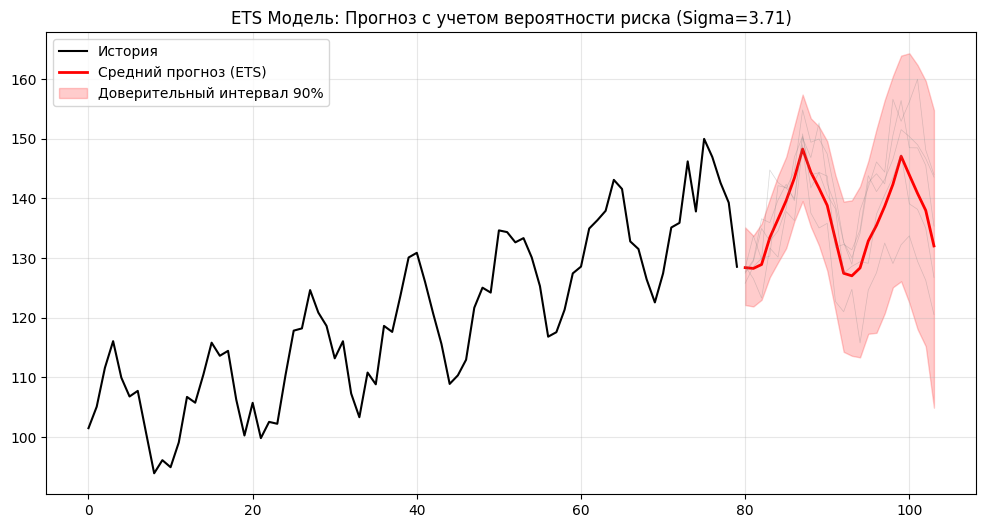

Оценка шума в данных (Sigma): 3.708
Это число показывает, насколько данные 'дерганые'.
Доверительный интервал строится на основе этого числа.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class EducationalETS:
    """
    Модель ETS(A, A, A) - Additive Error, Additive Trend, Additive Seasonality.

    Главная фишка: Уравнения записаны в форме коррекции ошибок (Error Correction),
    и мы моделируем случайность для построения интервалов.
    """
    def __init__(self, m, alpha, beta, gamma, phi=1.0):
        # phi - параметр Damping (затухание тренда).
        # Если phi=1.0, тренд линейный (как у Хольта).
        # Если phi=0.9, тренд будет замедляться.
        self.m = m
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.phi = phi

        # Состояния
        self.level = None
        self.trend = None
        self.seasonals = []

        # Статистика ошибок
        self.residuals = []   # История ошибок (e_t)
        self.sigma = 0        # Стандартное отклонение ошибок (разброс)

    def fit(self, data):
        self.residuals = []
        self.fitted_values = []

        # --- 1. Инициализация (по первому сезону) ---
        self.level = np.mean(data[:self.m])
        self.trend = (data[self.m] - data[0]) / self.m # Упрощенно

        # Начальная сезонность (Вычитание, т.к. Аддитивная)
        for i in range(self.m):
            self.seasonals.append(data[i] - self.level)
            # Заглушка для графика на старте
            self.fitted_values.append(data[i])

        # --- 2. Основной цикл (Форма Коррекции Ошибок) ---
        for t in range(self.m, len(data)):
            y_t = data[t]

            # --- Шаг А: Делаем прогноз "на один шаг" ---
            # Мы еще не видели Y_t, используем старые данные
            # Forecast = (L_old + phi * B_old) + S_old

            prev_level = self.level
            prev_trend = self.trend
            prev_seasonal = self.seasonals[t - self.m]

            # Предварительный прогноз (y_hat)
            y_hat = prev_level + self.phi * prev_trend + prev_seasonal

            # --- Шаг Б: Считаем ОШИБКУ (Error) ---
            # e_t = Факт - Прогноз
            e_t = y_t - y_hat
            self.residuals.append(e_t)
            self.fitted_values.append(y_hat)

            # --- Шаг В: Обновляем состояния через Ошибку ---
            # Если e_t > 0 (прогноз занижен), мы увеличиваем уровень.
            # Если e_t < 0 (прогноз завышен), мы уменьшаем уровень.

            # 1. Level = L_old + phi*B_old + alpha * ERROR
            self.level = prev_level + self.phi * prev_trend + self.alpha * e_t

            # 2. Trend = phi*B_old + beta * ERROR
            self.trend = self.phi * prev_trend + self.beta * e_t

            # 3. Season = S_old + gamma * ERROR
            new_seasonal = prev_seasonal + self.gamma * e_t
            self.seasonals.append(new_seasonal)

        # Считаем разброс ошибок (sigma), чтобы знать "силу шума" для симуляции
        self.sigma = np.std(self.residuals)

    def simulate(self, steps, n_simulations=100):
        """
        Киллер-фича ETS: Генерация множества вариантов будущего.
        """
        simulations = np.zeros((n_simulations, steps))

        # Берем последние известные состояния
        last_level = self.level
        last_trend = self.trend
        # Последние m сезонных компонент
        last_seasonals = self.seasonals[-self.m:]

        # Запускаем 100 параллельных вселенных
        for i in range(n_simulations):

            # Копируем состояния для этой ветки реальности
            curr_l = last_level
            curr_b = last_trend
            curr_s_list = list(last_seasonals) # Копия списка

            for h in range(steps):
                # 1. Генерируем случайную ошибку (Шум)
                # Берем из нормального распределения с нашей sigma
                noise = np.random.normal(0, self.sigma)

                # 2. Берем сезонность
                s_t = curr_s_list[h % self.m] # Упрощенный цикл для симуляции

                # 3. Делаем прогноз с учетом шума!
                # Y = (L + phi*B) + S + Noise
                forecast = (curr_l + self.phi * curr_b) + s_t + noise

                # 4. Обновляем внутренние состояния этой симуляции
                # (ведь будущая ошибка повлияет на прогноз послезавтра)
                curr_l = curr_l + self.phi * curr_b + self.alpha * noise
                curr_b = self.phi * curr_b + self.beta * noise
                # Обновляем сезонность в списке (добавляем в конец)
                new_s = s_t + self.gamma * noise
                curr_s_list.append(new_s)

                simulations[i, h] = forecast

        return simulations

# ==========================================================
# ПРИМЕР РАБОТЫ
# ==========================================================

# 1. Генерируем данные (Линейный тренд + Сезон + Шум)
np.random.seed(42)
time = np.arange(80)
trend = 0.5 * time
season = 10 * np.sin(2 * np.pi * time / 12) # Синус, период 12
noise = np.random.normal(0, 3, 80) # Шум со стандартным откл 3
data = 100 + trend + season + noise

# 2. Обучаем ETS
# alpha=0.2, beta=0.05, gamma=0.1
# phi=0.98 (Тренд будет потихоньку затухать, а не лететь в бесконечность)
ets_model = EducationalETS(m=12, alpha=0.2, beta=0.05, gamma=0.1, phi=0.98)
ets_model.fit(data)

# 3. СИМУЛЯЦИЯ БУДУЩЕГО
forecast_steps = 24 # 2 года
sim_paths = ets_model.simulate(forecast_steps, n_simulations=200)

# Считаем среднее (точечный прогноз) и границы (интервалы)
mean_forecast = np.mean(sim_paths, axis=0)
lower_bound = np.percentile(sim_paths, 5, axis=0)  # 5% квантиль (худший случай)
upper_bound = np.percentile(sim_paths, 95, axis=0) # 95% квантиль (лучший случай)

# 4. ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(12, 6))

# История
plt.plot(data, color='black', label='История', linewidth=1.5)

# Прогноз (Среднее)
x_future = np.arange(len(data), len(data) + forecast_steps)
plt.plot(x_future, mean_forecast, color='red', label='Средний прогноз (ETS)', linewidth=2)

# Доверительный интервал (Заливка)
plt.fill_between(x_future, lower_bound, upper_bound, color='red', alpha=0.2, label='Доверительный интервал 90%')

# Нарисуем пару тонких линий симуляции для наглядности
for i in range(5):
    plt.plot(x_future, sim_paths[i], color='gray', alpha=0.3, linewidth=0.5)

plt.title(f'ETS Модель: Прогноз с учетом вероятности риска (Sigma={ets_model.sigma:.2f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. ТЕКСТОВЫЙ ВЫВОД
print(f"Оценка шума в данных (Sigma): {ets_model.sigma:.3f}")
print("Это число показывает, насколько данные 'дерганые'.")
print("Доверительный интервал строится на основе этого числа.")


In [4]:
def a(c, *params):
    return list(params), c

a(1, 2, 3, 4)

([2, 3, 4], 1)

In [ ]:
def fit(y, alpha = 0.5):
    y_start = y.mean()
    n = len(y)
    pred = np.zeros(n)
    for i in range(n):
        pred = alpha*y[i] + (1-alpha)*pred
        pred[i] = pred
